<a href="https://colab.research.google.com/github/Carltonmwalumba/fish-farming-land-suitability-analysis-Taita-Taveta/blob/main/fish_farming_taita_taveta_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐟 Fish Farming Site Suitability Analysis
## Taita Taveta County, Kenya — Google Earth Engine
### Self-contained Google Colab Notebook
Multi-Criteria Evaluation using SRTM · CHIRPS · ESA WorldCover · JRC GSW · GRIP4

## 📦 Cell 1 — Install Dependencies

In [ ]:
!pip install earthengine-api geemap matplotlib numpy -q
print('✔ Dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 11.8 MB/s eta 0:00:00
✔ Dependencies installed.


## 🔑 Cell 2 — Authenticate & Initialise GEE

In [ ]:
import ee
import geemap

# Authenticate (opens a browser popup — follow the link, paste the token)
ee.Authenticate()

# ⚠ Replace with your GEE Cloud Project ID
GEE_PROJECT = 'ee-my-carlton1'

ee.Initialize(project=GEE_PROJECT)
print('✔ GEE initialised.')

KeyboardInterrupt: 

## ⚙️ Cell 3 — Configuration (edit weights & thresholds here)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Study area ────────────────────────────────────────────────────────────
COUNTY    = 'Taita Taveta'
BBOX      = [37.5, -4.2, 38.6, -2.8]   # [west, south, east, north]

# ── GEE dataset IDs ───────────────────────────────────────────────────────
DATASETS = {
    'dem'       : 'USGS/SRTMGL1_003',
    'chirps'    : 'UCSB-CHG/CHIRPS/DAILY',
    'worldcover': 'ESA/WorldCover/v200',
    'gaul2'     : 'FAO/GAUL/2015/level2',
    'jsw'       : 'JRC/GSW1_4/GlobalSurfaceWater',
    'roads'     : 'projects/sat-io/open-datasets/GRIP4/Africa',
}

# ── Rainfall period ───────────────────────────────────────────────────────
CHIRPS_START = '2014-01-01'
CHIRPS_END   = '2025-12-31'

# ── Export settings ───────────────────────────────────────────────────────
EXPORT_SCALE  = 500          # metres per pixel
EXPORT_CRS    = 'EPSG:32737' # UTM Zone 37S
DRIVE_FOLDER  = 'FishFarming_TaitaTaveta'

# ── Criterion weights (must sum to 1.0) ───────────────────────────────────
WEIGHTS = {
    'water_proximity': 0.25,
    'rainfall'       : 0.20,
    'slope'          : 0.20,
    'elevation'      : 0.15,
    'landuse'        : 0.10,
    'road_proximity' : 0.10,
}

# ── Scoring breakpoints (min, max, score) — score range 1–5 ──────────────
SLOPE_BREAKS      = [(0,2,5),(2,5,4),(5,10,3),(10,15,2),(15,90,1)]
ELEVATION_BREAKS  = [(0,500,3),(500,1200,5),(1200,1800,4),(1800,2200,2),(2200,6000,1)]
RAINFALL_BREAKS   = [(0,400,1),(400,600,2),(600,800,3),(800,1100,5),(1100,1400,4),(1400,3000,2)]
WATER_DIST_BREAKS = [(0,500,5),(500,1000,4),(1000,2000,3),(2000,3500,2),(3500,100000,1)]
ROAD_DIST_BREAKS  = [(0,2000,5),(2000,5000,4),(5000,10000,3),(10000,20000,2),(20000,100000,1)]

# ESA WorldCover class → score
LANDUSE_FROM = [10, 20, 30, 40, 50, 60, 80, 90, 95, 100]
LANDUSE_TO   = [ 2,  4,  5,  3,  1,  3,  1,  4,  2,   3]

# ── Hotspot classes & colours ─────────────────────────────────────────────
HOTSPOT_CLASSES = {
    'Highly Suitable'    : (4.0, 5.01),
    'Moderately Suitable': (3.0, 4.0),
    'Marginally Suitable': (2.0, 3.0),
    'Not Suitable'       : (1.0, 2.0),
}
HOTSPOT_COLORS = {
    'Highly Suitable'    : '#1a7f37',
    'Moderately Suitable': '#74c476',
    'Marginally Suitable': '#fdae6b',
    'Not Suitable'       : '#d62728',
}

# Output directory (Colab local storage)
OUTPUT_DIR = '/content/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✔ Configuration loaded.')
print(f'  Weights: {WEIGHTS}')

✔ Configuration loaded.
  Weights: {'water_proximity': 0.25, 'rainfall': 0.2, 'slope': 0.2, 'elevation': 0.15, 'landuse': 0.1, 'road_proximity': 0.1}


## 🗺️ Cell 4 — Define Study Area

In [ ]:
west, south, east, north = BBOX
roi = ee.Geometry.Rectangle([west, south, east, north])

# Fetch real county boundary from FAO GAUL
gaul = ee.FeatureCollection(DATASETS['gaul2'])
boundary = gaul.filter(
    ee.Filter.And(
        ee.Filter.eq('ADM0_NAME', 'Kenya'),
        ee.Filter.eq('ADM2_NAME', COUNTY),
    )
)

count = boundary.size().getInfo()
if count > 0:
    roi = boundary.geometry()
    print(f'✔ {COUNTY} county boundary loaded ({count} feature).')
else:
    boundary = ee.FeatureCollection([ee.Feature(roi, {'name': COUNTY})])
    print('⚠ County not found in GAUL — using bounding box.')

# Preview map
m0 = geemap.Map()
m0.centerObject(roi, zoom=9)
m0.add_basemap('HYBRID')
m0.addLayer(
    boundary.style(color='red', width=2, fillColor='FF000022'),
    {}, f'{COUNTY} Boundary'
)
m0

✔ Taita Taveta county boundary loaded (1 feature).


Map(center=[-3.4350833923681363, 38.421433915728876], controls=(WidgetControl(options=['position', 'transparen…

## 🧮 Cell 5 — Suitability Scoring Functions

In [ ]:
# ── Helper: stepped reclassification ─────────────────────────────────────
def stepped_score(image, breaks):
    """Reclassify continuous ee.Image into integer scores 1–5."""
    scored = ee.Image(breaks[-1][2]).float()
    for lo, hi, score in reversed(breaks[:-1]):
        condition = image.gte(lo).And(image.lt(hi))
        scored = scored.where(condition, ee.Image(score).float())
    return scored


# ── Layer 1: Elevation ────────────────────────────────────────────────────
def score_elevation(roi):
    print('  Scoring elevation …')
    dem = ee.Image(DATASETS['dem']).select('elevation').clip(roi)
    return stepped_score(dem, ELEVATION_BREAKS).rename('elevation_score')


# ── Layer 2: Slope ────────────────────────────────────────────────────────
def score_slope(roi):
    print('  Scoring slope …')
    dem   = ee.Image(DATASETS['dem']).select('elevation').clip(roi)
    slope = ee.Terrain.slope(dem)
    return stepped_score(slope, SLOPE_BREAKS).rename('slope_score')


# ── Layer 3: Rainfall (CHIRPS annual mean) ────────────────────────────────
def score_rainfall(roi):
    print('  Scoring rainfall (CHIRPS 10-year mean) …')
    chirps = (
        ee.ImageCollection(DATASETS['chirps'])
        .filterDate(CHIRPS_START, CHIRPS_END)
        .filterBounds(roi)
        .select('precipitation')
    )
    years = ee.List.sequence(2014, 2023)
    def annual_total(y):
        y     = ee.Number(y)
        start = ee.Date.fromYMD(y, 1, 1)
        end   = ee.Date.fromYMD(y, 12, 31)
        return chirps.filterDate(start, end).sum().set('year', y)
    mean_annual = ee.ImageCollection(years.map(annual_total)).mean().clip(roi)
    return stepped_score(mean_annual, RAINFALL_BREAKS).rename('rainfall_score')


# ── Layer 4: Distance to water (JRC Global Surface Water) ─────────────────
def score_water_proximity(roi):
    print('  Scoring water proximity …')
    gsw        = ee.Image(DATASETS['jsw']).select('occurrence').clip(roi)
    water_mask = gsw.gte(50).selfMask()
    distance   = (
        water_mask
        .distance(ee.Kernel.euclidean(radius=100000, units='meters'))
        .unmask(100000)
        .clip(roi)
    )
    return stepped_score(distance, WATER_DIST_BREAKS).rename('water_proximity_score')


# ── Layer 5: Distance to roads (GRIP4) ───────────────────────────────────
def score_road_proximity(roi):
    print('  Scoring road proximity …')
    try:
        roads_fc    = ee.FeatureCollection(DATASETS['roads']).filterBounds(roi)
        road_raster = (
            roads_fc
            .map(lambda f: f.set('road', 1))
            .reduceToImage(properties=['road'], reducer=ee.Reducer.first())
            .gt(0).selfMask().clip(roi)
        )
        distance = (
            road_raster
            .distance(ee.Kernel.euclidean(radius=100000, units='meters'))
            .unmask(100000)
            .clip(roi)
        )
        return stepped_score(distance, ROAD_DIST_BREAKS).rename('road_proximity_score')
    except Exception as e:
        print(f'    ⚠ Road layer error ({e}) — using neutral score 3.')
        return ee.Image(3).float().clip(roi).rename('road_proximity_score')


# ── Layer 6: Land use (ESA WorldCover 2021) ───────────────────────────────
def score_landuse(roi):
    print('  Scoring land use (ESA WorldCover) …')
    wc = (
        ee.ImageCollection(DATASETS['worldcover'])
        .filterBounds(roi)
        .first()
        .select('Map')
        .clip(roi)
    )
    return wc.remap(LANDUSE_FROM, LANDUSE_TO).float().rename('landuse_score')


print('✔ Scoring functions defined.')

✔ Scoring functions defined.


## 🔢 Cell 6 — Build Scored Stack

In [ ]:
print('\n=== Scoring all suitability layers ===\n')

scored_stack = (
    score_elevation(roi)
    .addBands(score_slope(roi))
    .addBands(score_rainfall(roi))
    .addBands(score_water_proximity(roi))
    .addBands(score_road_proximity(roi))
    .addBands(score_landuse(roi))
)

print('\n✔ Scored stack ready.')
print('  Bands:', scored_stack.bandNames().getInfo())


=== Scoring all suitability layers ===

  Scoring elevation …
  Scoring slope …
  Scoring rainfall (CHIRPS 10-year mean) …
  Scoring water proximity …
  Scoring road proximity …
  Scoring land use (ESA WorldCover) …

✔ Scored stack ready.
  Bands: ['elevation_score', 'slope_score', 'rainfall_score', 'water_proximity_score', 'road_proximity_score', 'landuse_score']


## 🔍 Cell 7 — Inspect Individual Scored Layers

In [ ]:
score_vis = {
    'min': 1, 'max': 5,
    'palette': ['d62728', 'fdae6b', 'ffffb2', '74c476', '1a7f37'],
}

m1 = geemap.Map()
m1.centerObject(roi, zoom=9)
m1.add_basemap('HYBRID')

for band, label in [
    ('elevation_score',       'Elevation Score'),
    ('slope_score',           'Slope Score'),
    ('rainfall_score',        'Rainfall Score'),
    ('water_proximity_score', 'Water Proximity Score'),
    ('road_proximity_score',  'Road Proximity Score'),
    ('landuse_score',         'Land Use Score'),
]:
    m1.addLayer(scored_stack.select(band), score_vis, label, False)

# Show elevation score by default
m1.addLayer(scored_stack.select('elevation_score'), score_vis, 'Elevation Score (ON)', True)
m1.addLayer(boundary.style(color='white', width=2, fillColor='00000000'), {}, 'Boundary')
m1.add_colorbar(score_vis, label='Score (1 = Low Suitability → 5 = High Suitability)',
                orientation='horizontal', position='bottomleft')
m1

Map(center=[-3.4350833923681363, 38.421433915728876], controls=(WidgetControl(options=['position', 'transparen…

## ⚖️ Cell 8 — Weighted Overlay & Hotspot Classification

In [ ]:
BAND_MAP = {
    'elevation'      : 'elevation_score',
    'slope'          : 'slope_score',
    'rainfall'       : 'rainfall_score',
    'water_proximity': 'water_proximity_score',
    'road_proximity' : 'road_proximity_score',
    'landuse'        : 'landuse_score',
}

# Weighted overlay
print('Running weighted overlay …')
composite = ee.Image(0).float()
for key, weight in WEIGHTS.items():
    band = BAND_MAP[key]
    composite = composite.add(scored_stack.select(band).multiply(weight))
suitability = composite.rename('suitability_index').clip(roi)

# Hotspot classification
print('Classifying hotspot zones …')
hotspot = (
    ee.Image(0)
    .where(suitability.gte(1.0).And(suitability.lt(2.0)), 1)  # Not Suitable
    .where(suitability.gte(2.0).And(suitability.lt(3.0)), 2)  # Marginally
    .where(suitability.gte(3.0).And(suitability.lt(4.0)), 3)  # Moderately
    .where(suitability.gte(4.0),                          4)  # Highly
    .rename('hotspot_class')
    .clip(roi)
)

print('✔ Suitability index and hotspot classes computed.')

Running weighted overlay …
Classifying hotspot zones …
✔ Suitability index and hotspot classes computed.


## 🗺️ Cell 9 — Final Interactive Hotspot Map

In [ ]:
suit_vis = {
    'min': 1, 'max': 5,
    'palette': ['d62728', 'fdae6b', 'ffffb2', '74c476', '1a7f37'],
}
hotspot_vis = {
    'min': 1, 'max': 4,
    'palette': ['d62728', 'fdae6b', '74c476', '1a7f37'],
}

m2 = geemap.Map()
m2.centerObject(roi, zoom=9)
m2.add_basemap('HYBRID')

m2.addLayer(suitability, suit_vis,    'Suitability Index (1–5)', True)
m2.addLayer(hotspot,     hotspot_vis, 'Hotspot Classes',         False)

# Individual layers (toggle off by default)
score_vis = {'min':1,'max':5,'palette':['d62728','fdae6b','ffffb2','74c476','1a7f37']}
for band, label in [
    ('elevation_score',       'Elevation Score'),
    ('slope_score',           'Slope Score'),
    ('rainfall_score',        'Rainfall Score'),
    ('water_proximity_score', 'Water Proximity'),
    ('road_proximity_score',  'Road Proximity'),
    ('landuse_score',         'Land Use Score'),
]:
    m2.addLayer(scored_stack.select(band), score_vis, label, False)

m2.addLayer(
    boundary.style(color='white', width=2, fillColor='00000000'),
    {}, f'{COUNTY} Boundary'
)

legend_dict = {
    'Highly Suitable (4–5)'    : '#1a7f37',
    'Moderately Suitable (3–4)': '#74c476',
    'Marginally Suitable (2–3)': '#fdae6b',
    'Not Suitable (1–2)'       : '#d62728',
}
m2.add_legend(
    title='Fish Farming Suitability',
    legend_dict=legend_dict,
    position='bottomright',
)
m2.add_colorbar(
    suit_vis, label='Suitability Index',
    orientation='horizontal', position='bottomleft', transparent_bg=True,
)
m2

Map(center=[-3.435083392368128, 38.421433915728876], controls=(WidgetControl(options=['position', 'transparent…

## 📊 Cell 10 — Statistics & Area Summary

In [ ]:
# Summary statistics
print('Computing summary statistics …')
stats = suitability.reduceRegion(
    reducer=(
        ee.Reducer.mean()
        .combine(ee.Reducer.stdDev(), sharedInputs=True)
        .combine(ee.Reducer.min(),    sharedInputs=True)
        .combine(ee.Reducer.max(),    sharedInputs=True)
    ),
    geometry=roi,
    scale=EXPORT_SCALE,
    maxPixels=1e9,
    bestEffort=True,
).getInfo()

print('\n--- Suitability Index Statistics ---')
for k, v in stats.items():
    print(f'  {k:45s}: {v:.4f}' if v else f'  {k}: None')

# Hotspot areas
print('\n--- Hotspot Area (km²) ---')
pixel_area = ee.Image.pixelArea().divide(1e6)
class_map  = {1:'Not Suitable', 2:'Marginally Suitable',
               3:'Moderately Suitable', 4:'Highly Suitable'}
areas = {}
for cid, cname in class_map.items():
    result = (
        pixel_area
        .updateMask(hotspot.eq(cid))
        .reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=roi,
            scale=EXPORT_SCALE,
            maxPixels=1e9,
            bestEffort=True,
        ).getInfo()
    )
    km2 = list(result.values())[0] if result else 0
    areas[cname] = round(km2, 1)
    print(f'  {cname:25s}: {km2:>8.1f} km²')

print(f'\n  Total: {sum(areas.values()):,.1f} km²')

Computing summary statistics …

--- Suitability Index Statistics ---
  suitability_index_max                        : 4.7000
  suitability_index_mean                       : 3.0876
  suitability_index_min                        : 1.5000
  suitability_index_stdDev                     : 0.2888

--- Hotspot Area (km²) ---
  Not Suitable             :     23.2 km²
  Marginally Suitable      :   5585.1 km²
  Moderately Suitable      :  11647.7 km²
  Highly Suitable          :     44.4 km²

  Total: 17,300.4 km²


## 📈 Cell 11 — Summary Chart

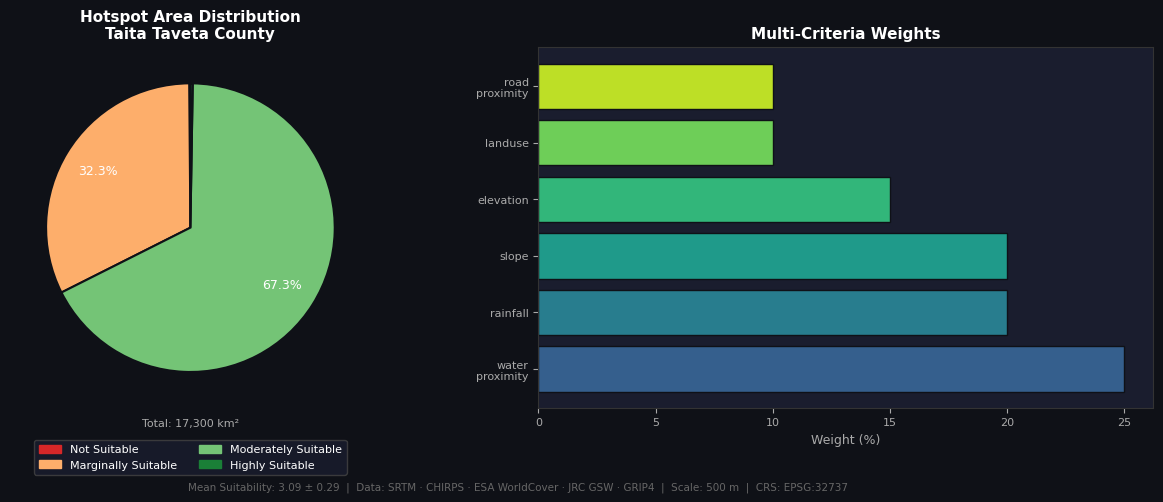

✔ Chart saved → /content/outputs/hotspot_summary_chart.png


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), facecolor='#0f1117')
fig.patch.set_facecolor('#0f1117')

# ── Pie: area by hotspot class ─────────────────────────────────────────────
ax1.set_facecolor('#0f1117')
pie_labels = list(areas.keys())
pie_values = [areas[l] for l in pie_labels]
pie_colors = [HOTSPOT_COLORS[l] for l in pie_labels]
ax1.pie(
    pie_values, labels=None, colors=pie_colors,
    autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
    pctdistance=0.75, startangle=90,
    wedgeprops={'linewidth': 1.5, 'edgecolor': '#0f1117'},
    textprops={'color': 'white', 'fontsize': 9},
)
patches = [mpatches.Patch(color=c, label=l)
           for l, c in zip(pie_labels, pie_colors)]
ax1.legend(handles=patches, loc='lower center',
           bbox_to_anchor=(0.5, -0.2), ncol=2,
           facecolor='#1a1d2e', edgecolor='#444',
           labelcolor='white', fontsize=8)
ax1.set_title(f'Hotspot Area Distribution\n{COUNTY} County',
              color='white', fontsize=11, fontweight='bold')
ax1.text(0, -1.38, f'Total: {sum(pie_values):,.0f} km²',
         ha='center', color='#aaa', fontsize=8, transform=ax1.transData)

# ── Bar: criterion weights ─────────────────────────────────────────────────
ax2.set_facecolor('#1a1d2e')
w_labels = [k.replace('_', '\n') for k in WEIGHTS]
w_values = [v * 100 for v in WEIGHTS.values()]
bar_colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(w_values)))
ax2.barh(w_labels, w_values, color=bar_colors, edgecolor='#0f1117')
ax2.set_xlabel('Weight (%)', color='#aaa', fontsize=9)
ax2.set_title('Multi-Criteria Weights', color='white',
              fontsize=11, fontweight='bold')
ax2.tick_params(colors='#aaa', labelsize=8)
for spine in ax2.spines.values():
    spine.set_edgecolor('#333')

mean_val = stats.get('suitability_index_mean', 0) or 0
std_val  = stats.get('suitability_index_stdDev', 0) or 0
fig.text(
    0.5, 0.01,
    f'Mean Suitability: {mean_val:.2f} ± {std_val:.2f}  |  '
    f'Data: SRTM · CHIRPS · ESA WorldCover · JRC GSW · GRIP4  |  '
    f'Scale: {EXPORT_SCALE} m  |  CRS: {EXPORT_CRS}',
    ha='center', color='#666', fontsize=7.5,
)

plt.tight_layout()
chart_path = f'{OUTPUT_DIR}/hotspot_summary_chart.png'
plt.savefig(chart_path, dpi=180, bbox_inches='tight',
            facecolor='#0f1117', edgecolor='none')
plt.show()
print(f'✔ Chart saved → {chart_path}')

## 📤 Cell 12 — Export GeoTIFFs to Google Drive

In [ ]:
print(f'Exporting to Google Drive folder: {DRIVE_FOLDER}\n')

exports = [
    (suitability.toFloat(), 'suitability_index',     'suitability_index_taita_taveta'),
    (hotspot.toInt(),       'hotspot_classes',        'hotspot_classes_taita_taveta'),
    (scored_stack.toFloat(),'scored_layers_stack',    'scored_layers_taita_taveta'),
]

tasks = []
for image, desc, filename in exports:
    task = ee.batch.Export.image.toDrive(
        image          = image,
        description    = desc,
        folder         = DRIVE_FOLDER,
        fileNamePrefix = filename,
        region         = roi,
        scale          = EXPORT_SCALE,
        crs            = EXPORT_CRS,
        maxPixels      = 1e9,
        fileFormat     = 'GeoTIFF',
    )
    task.start()
    tasks.append((desc, task))
    print(f'  ✔ Submitted: {filename}.tif  [{task.id}]')

print(f'\n{len(tasks)} task(s) running.')
print('Monitor at: https://code.earthengine.google.com/tasks')

## 🔄 Cell 13 (Optional) — Sensitivity Analysis: Adjust Weights & Re-run

In [ ]:
# Edit weights below, then re-run this cell + Cell 8 onwards
WEIGHTS = {
    'water_proximity': 0.35,   # ← increased
    'rainfall'       : 0.20,
    'slope'          : 0.20,
    'elevation'      : 0.15,
    'landuse'        : 0.10,
    'road_proximity' : 0.00,   # ← removed
}

# Auto-normalise so they always sum to 1
total  = sum(WEIGHTS.values())
WEIGHTS = {k: round(v / total, 4) for k, v in WEIGHTS.items()}
print('Normalised weights:', WEIGHTS)
print('Sum:', sum(WEIGHTS.values()))

# Re-run overlay with new weights
composite2 = ee.Image(0).float()
for key, weight in WEIGHTS.items():
    band = BAND_MAP[key]
    composite2 = composite2.add(scored_stack.select(band).multiply(weight))
suitability2 = composite2.rename('suitability_index').clip(roi)

hotspot2 = (
    ee.Image(0)
    .where(suitability2.gte(1.0).And(suitability2.lt(2.0)), 1)
    .where(suitability2.gte(2.0).And(suitability2.lt(3.0)), 2)
    .where(suitability2.gte(3.0).And(suitability2.lt(4.0)), 3)
    .where(suitability2.gte(4.0),                           4)
    .rename('hotspot_class').clip(roi)
)

m3 = geemap.Map()
m3.centerObject(roi, zoom=9)
m3.add_basemap('HYBRID')
m3.addLayer(suitability2, suit_vis, 'Suitability (adjusted weights)', True)
m3.addLayer(boundary.style(color='white', width=2, fillColor='00000000'), {}, 'Boundary')
m3.add_legend(title='Suitability', legend_dict=legend_dict, position='bottomright')
m3